In [9]:
import h5py
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from ptychozoon.enhance import ElementMap, FluorescenceDataset, Product, VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.settings import DeconvolutionEnhancementSettings
from ptychozoon.settings import InterpolationTypes

from chronos import plotting
from chronos.timer_utils import toggle_timer, clear_timer_globals

import sys
sys.path.append("/home/beams1/B222816/scripts/readMDA.py")
from readMDA import *

## Load data

In [14]:

# get relevant xrf data
file_path = (
    "/net/micdata/data1/bnp/2023-1/Isaure_fly0085_for_SH/img.dat/bnp_fly0085.mda.h5"
)
with h5py.File(file_path, "r") as F:
    channel_names = [x.decode() for x in F["/MAPS/channel_names"][()]]
    element_maps = []
    for i, channel in enumerate(channel_names):
        element_maps += [
            ElementMap(channel, F["/MAPS/XRF_Analyzed/NNLS/Counts_Per_Sec"][i])
        ]
    xrf_pos_x = F["MAPS/x_axis"][()]
    xrf_pos_y = F["MAPS/y_axis"][()]
flourescence_in = FluorescenceDataset(element_maps)


# get ptycho data
file_path = "/net/micdata/data1/bnp/2023-1/Isaure_fly0085_for_SH/results/ML_recon/fly085/roi0_Ndp256/MLs_L1_p10_g1000_Ndp64_pc50_noModelCon_bg0.1_vp5_vi_mm/Niter1000.mat"
d = sio.loadmat(file_path)
pixel_size_m = d["p"]["dx_spec"][0][0][0][0]
ptycho_in = Product(
    # probe_positions=d["outputs"]["probe_positions"][0][0] * pixel_size_m,
    probe_positions=np.roll(d["outputs"]["probe_positions"][0][0] * pixel_size_m, 1) * 1,
    probe=d["probe"][:, :, :, 0].transpose(
        [2, 0, 1]
        # [2, 1, 0]
    ),  # removing opr for now. Might need to be transposed.
    object_array=d["object"],
    pixel_size_m=(pixel_size_m,) * 2,
    object_center_m = np.array([0, 0])
    # object_center_m=np.roll((np.array(d["object"].shape) / 2) * pixel_size_m, 0),
)

# get invalid indices
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]
xrf_shape = flourescence_in.element_maps[2].counts_per_second.shape
n_points = np.prod(xrf_shape)
invalid_position_index = [x for x in range(0, n_points) if x not in valid_position_index]


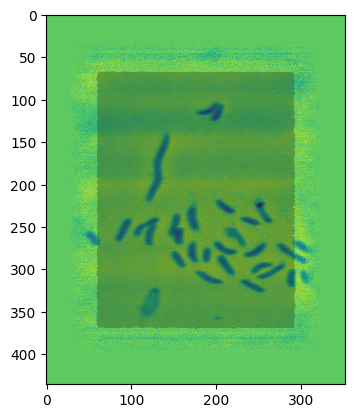

In [26]:
plt.imshow(np.angle(ptycho_in.object_array))
plt.plot(
    (ptycho_in.probe_positions[:, 1]/pixel_size_m + ptycho_in.object_array.shape[1] / 2),
    (ptycho_in.probe_positions[:, 0]/pixel_size_m + ptycho_in.object_array.shape[0] / 2),
    "k",
    alpha=0.25,
)
plt.show()

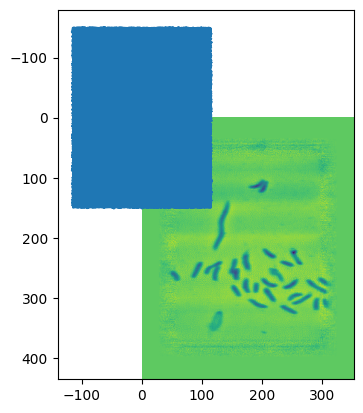

In [4]:
plt.imshow(np.angle(ptycho_in.object_array))
plt.plot(ptycho_in.probe_positions[:, 1]/pixel_size_m, ptycho_in.probe_positions[:, 0]/pixel_size_m)
plt.show()

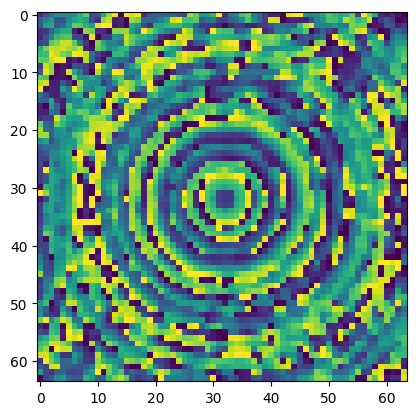

In [27]:
plt.imshow(np.angle(ptycho_in.probe[0]))
plt.clim([-3,3])
plt.show()

## test vspi

In [11]:
from ptychozoon.settings import InterpolationTypes


clear_timer_globals()
toggle_timer(True)
flourescence_result = VSPIFluorescenceEnhancingAlgorithm(max_iterations=10).enhance(
    flourescence_in,
    ptycho_in,
    valid_position_index,
    # select_maps=["Fe", "K", "P", "S", "Zn"],
    select_maps=["K"],
    use_gpu=True,
    settings=DeconvolutionEnhancementSettings(interpolation=InterpolationTypes.FOURIER)
)

In [26]:
import importlib
import ptychozoon
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
importlib.reload(ptychozoon)
importlib.reload(ptychozoon.enhance)

<module 'ptychozoon.enhance' from '/home/beams0/HRUTH/code/ptycho_development/ptychozoon/src/ptychozoon/enhance.py'>

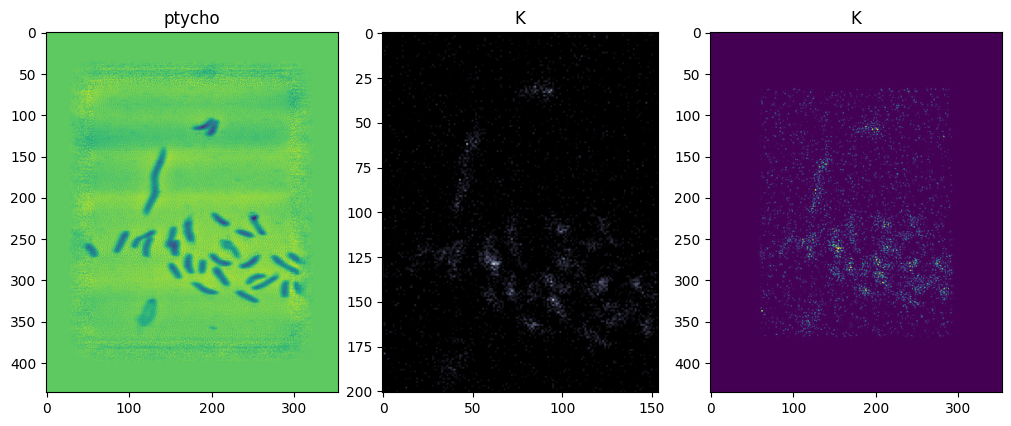

In [12]:
# 10 iterations, fourier
fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10, 10))
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second, cmap="bone")
plt.clim([0, 10])
plt.sca(ax[2])
plt.title(flourescence_result.element_maps[0].name)
plt.imshow(flourescence_result.element_maps[0].counts_per_second)# cmap="viridis")
plt.clim(0, 10)
# plt.clim([0, 10])
# plt.colorbar()
plt.show()

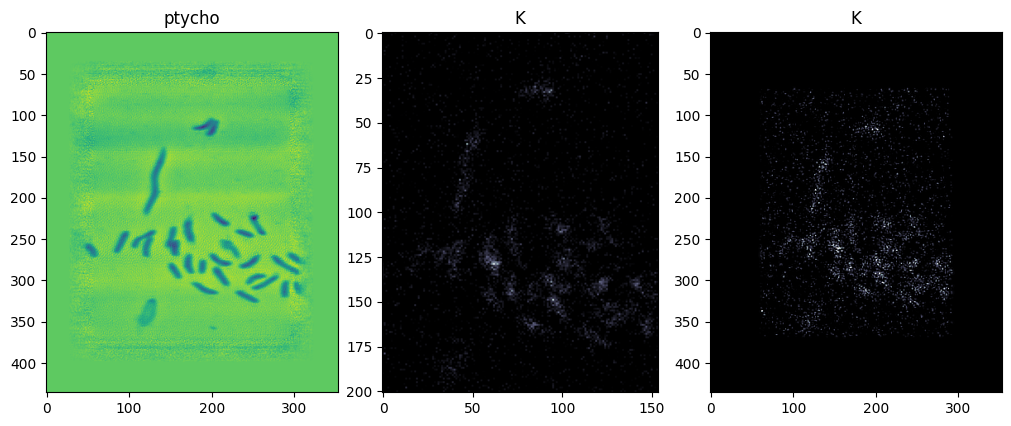

In [23]:
# 10 iterations, barycentric
fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10, 10))
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second, cmap="bone")
plt.clim([0, 10])
plt.sca(ax[2])
plt.title(flourescence_result.element_maps[0].name)
plt.imshow(flourescence_result.element_maps[0].counts_per_second, cmap="bone")
plt.clim([0, 10])
# plt.colorbar()
plt.show()

In [11]:
import importlib
import ptychozoon
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
importlib.reload(ptychozoon)
importlib.reload(ptychozoon.enhance)

<module 'ptychozoon.enhance' from '/home/beams0/HRUTH/code/ptycho_development/ptychozoon/src/ptychozoon/enhance.py'>

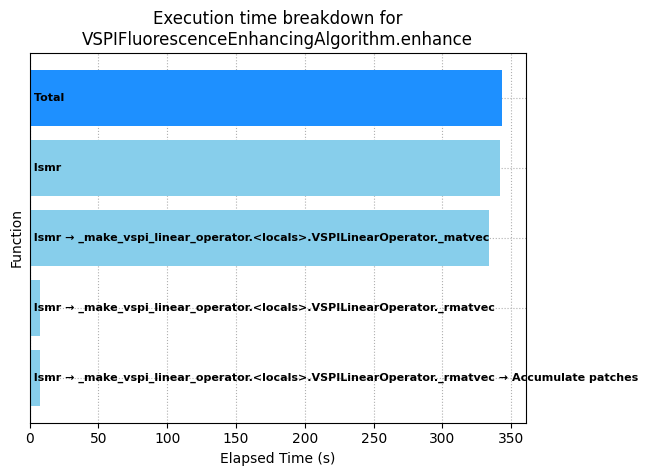

Execution summary of VSPIFluorescenceEnhancingAlgorithm.enhance

Total execution time: 343 s

Execution times:
Sorted by total execution time
1. lsmr: 3.4e+02 s
2. _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec: 3.3e+02 s
3. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec: 7.7 s
4. Accumulate patches: 7.7 s

Function call stack info:
Ordered by time of first function call
1. lsmr
2. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec
3. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches
4. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec


{'Total': np.float64(343.19307470321655),
 'lsmr': np.float64(341.7208721637726),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec': np.float64(7.711597204208374),
 'Accumulate patches': np.float64(7.686354875564575),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec': np.float64(333.7898573875427)}

In [7]:
# timin
plotting.plot_elapsed_time_bar_plot_advanced("VSPIFluorescenceEnhancingAlgorithm.enhance", sort=True, use_long_bar_labels=True, exclude_below_time_fraction=0.005)

In [5]:
import importlib
import ptychozoon
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
importlib.reload(ptychozoon)
importlib.reload(ptychozoon.enhance)

<module 'ptychozoon.enhance' from '/home/beams0/HRUTH/code/ptycho_development/ptychozoon/src/ptychozoon/enhance.py'>

In [ ]:
6.270408630371094e-05 * 30777 * 3

6.712840992507935

CPU
- Multiplication only: 5.8e-6 (low)
- Assignment: 2.2e-5
- Assignment and multiplication: 2.8e-5

GPU
- Multiplication only: 3.1e-5
- Assignment: 3.7e-5
- Assignment and multiplication: 6.8e-5


In [ ]:
# GPU is slower....!
print(f"GPU:CPU multiplication speed: {5.8e-6/3.1e-5:.2f}")
print(f"GPU:CPU assignment speed: {2.2e-5/3.7e-5:.2f}")
print(f"GPU:CPU overall speed: {2.8e-5/6.8e-5:.2f}")

GPU:CPU multiplication speed: 0.19
GPU:CPU assignment speed: 0.59
GPU:CPU overall speed: 0.41


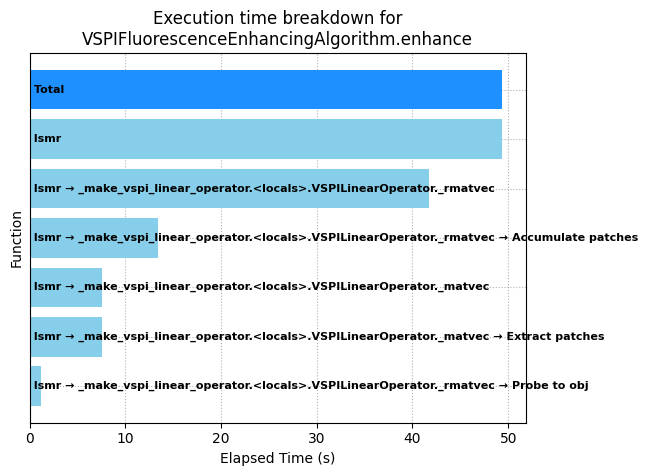

Execution summary of VSPIFluorescenceEnhancingAlgorithm.enhance

Total execution time: 49.3 s

Execution times:
Sorted by total execution time
1. lsmr: 49 s
2. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec: 42 s
3. Accumulate patches: 13 s
4. _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec: 7.6 s
5. Extract patches: 7.6 s
6. Probe to obj: 1.2 s

Function call stack info:
Ordered by time of first function call
1. lsmr
2. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec
3. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Probe to obj
4. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches
5. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec
6. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec → Extract patches


{'Total': np.float64(49.34640550613403),
 'lsmr': np.float64(49.343764543533325),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec': np.float64(41.774633169174194),
 'Probe to obj': np.float64(1.1793813705444336),
 'Accumulate patches': np.float64(13.434700012207031),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec': np.float64(7.565479278564453),
 'Extract patches': np.float64(7.564603567123413)}

In [31]:
# timin
plotting.plot_elapsed_time_bar_plot_advanced("VSPIFluorescenceEnhancingAlgorithm.enhance", sort=True, use_long_bar_labels=True)

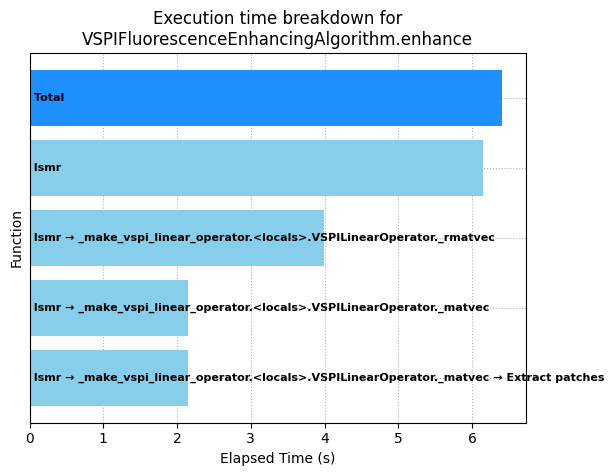

Execution summary of VSPIFluorescenceEnhancingAlgorithm.enhance

Total execution time: 6.41 s

Execution times:
Sorted by total execution time
1. lsmr: 6.2 s
2. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec: 4 s
3. _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec: 2.1 s
4. Extract patches: 2.1 s

Function call stack info:
Ordered by time of first function call
1. lsmr
2. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec
3. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec
4. lsmr → _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec → Extract patches


{'Total': np.float64(6.4053332805633545),
 'lsmr': np.float64(6.15462589263916),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec': np.float64(3.9985311031341553),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec': np.float64(2.147639274597168),
 'Extract patches': np.float64(2.146784782409668)}

In [4]:
# timing, using GPU
plotting.plot_elapsed_time_bar_plot_advanced("VSPIFluorescenceEnhancingAlgorithm.enhance", sort=True, use_long_bar_labels=True)

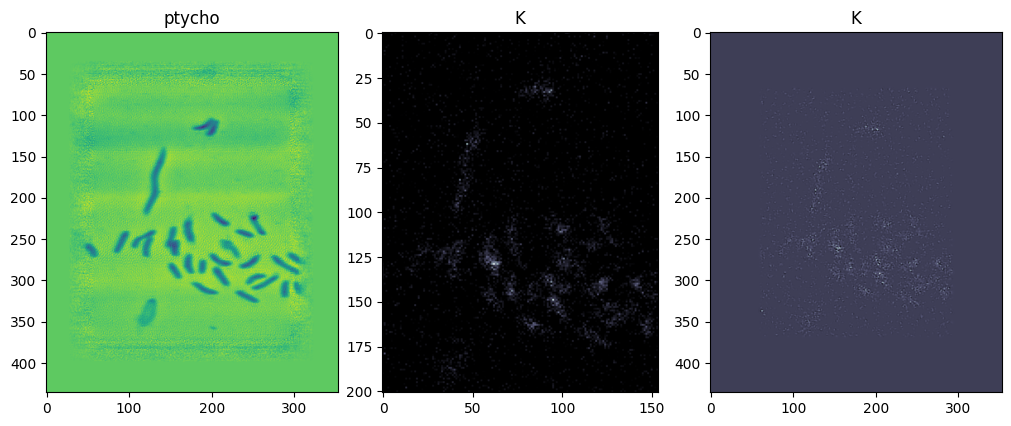

In [11]:
fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10, 10))
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second, cmap="bone")
plt.clim([0, 10])
plt.sca(ax[2])
plt.title(flourescence_result.element_maps[0].name)
plt.imshow(flourescence_result.element_maps[0].counts_per_second, cmap="bone")
# plt.clim(0, 30)
# plt.clim([0, 10])
# plt.colorbar()
plt.show()

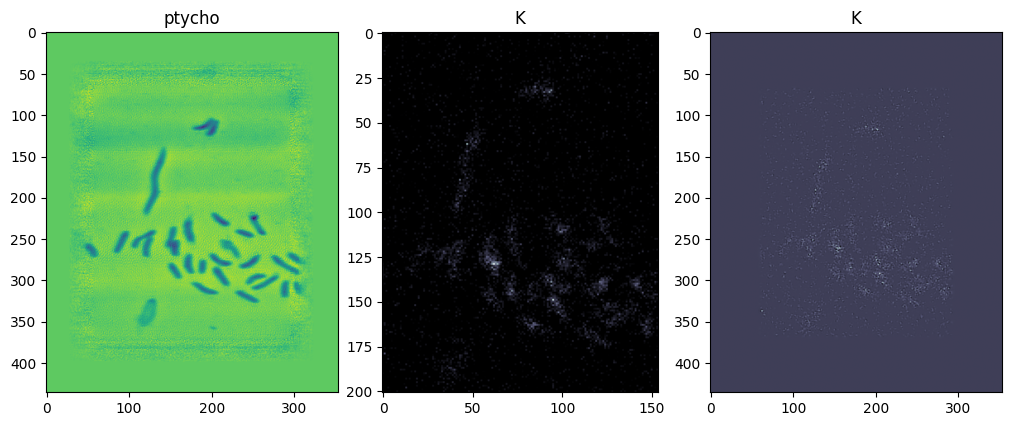

In [ ]:
fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10, 10))
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second, cmap="bone")
plt.clim([0, 10])
plt.sca(ax[2])
plt.title(flourescence_result.element_maps[0].name)
plt.imshow(flourescence_result.element_maps[0].counts_per_second, cmap="bone")
plt.clim(0, 30)
# plt.clim([0, 10])
# plt.colorbar()
plt.show()

100 iterations, no probe transpose
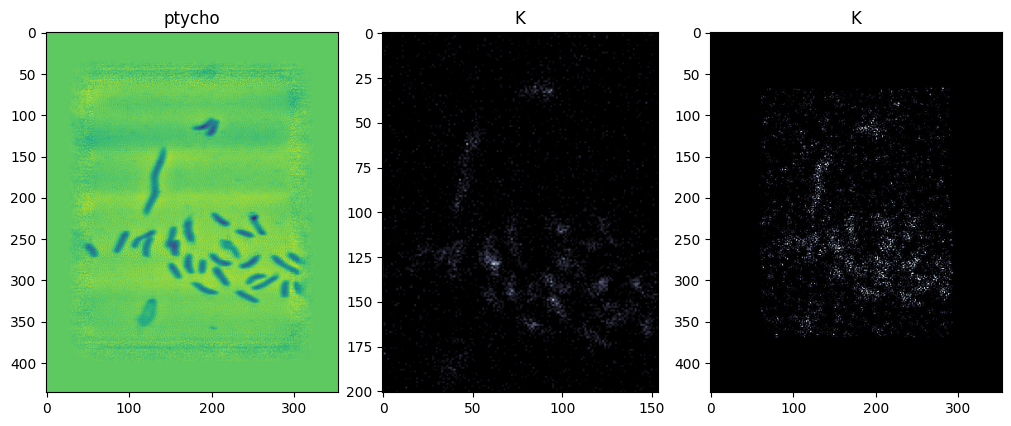

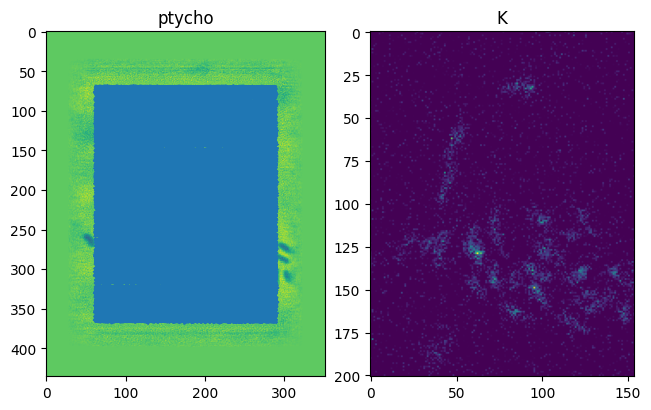

In [152]:
fig, ax = plt.subplots(1, 2, layout="compressed")
plt.sca(ax[0])
plt.title("ptycho")
plt.imshow(np.angle(ptycho_in.object_array))
plt.plot(
    ptycho_in.probe_positions[:, 0] / ptycho_in.pixel_size_m[0]
    + ptycho_in.object_center_m[0] / ptycho_in.pixel_size_m[0],
    ptycho_in.probe_positions[:, 1] / ptycho_in.pixel_size_m[0]
    + ptycho_in.object_center_m[1] / ptycho_in.pixel_size_m[0],
)
plt.sca(ax[1])
idx = 5
plt.title(flourescence_in.element_maps[idx].name)
plt.imshow(flourescence_in.element_maps[idx].counts_per_second)
plt.show()

## run code for finding stopped stage positions
Do not run again

### Make file with indexing results

In [2]:
#!/APSshare/anaconda/x86_64/bin/python
import h5py
import numpy as np
import os #for change directory
import scipy.io as sio #for read/write matlab file
from numpy import *
import time
import scipy.ndimage
import glob
import pdb

import sys
import csv


sys.path.append("/home/beams1/B222816/scripts")
from readMDA import *
import datetime

# scans=np.arange(95,1000,1)
scans = [85]
#scans=[41]
# user_dir='/mnt/micdata1/bnp/2023-1/Isaure/'
user_dir = '/net/micdata/data1/bnp/2023-1/Isaure/'
data_dir =user_dir+'ptycho/'
result_dir = user_dir+'results/ML_recon/fly{:03d}/'
#xrf_file = user_dir+'img.dat/bnp_fly{:04d}.mda.h5'
xrf_file = user_dir+'img.dat/bnp_fly{:04d}.mda.h5'
mda_file=user_dir+'mda/bnp_fly{:04d}.mda'



energy = 12.3
det_sample_dist = 2.0578
det_pixel_size = 75e-6
cen_x = 503
cen_y = 268
det_Npixel = 128
lam = 1.23984193e-9/energy
dx = lam*det_sample_dist/det_pixel_size/det_Npixel #pixel size
filePath = '/entry/data/data'
print("real-space pixel size: " + str(dx))

N_scan_x_lb = 0
N_scan_y_lb = 1
roi='0_Ndp' + str(det_Npixel)

# while True:
for scanNo in scans:
    
    data_dir_next = mda_file.format(scanNo)
    dataExist = os.path.isfile(data_dir_next)
    if not dataExist:
        print('Scan No.' + str(scanNo+1) + '-Data does not exist!')
        continue

    dataName = 'data_roi' + roi + '_dp.hdf5'
    dataExists = os.path.isfile(result_dir.format(scanNo)+dataName)
    if dataExists:
        print('Scan No.' + str(scanNo) + '-Data already exists!')
        continue    
    #pdb.set_trace()
    if not os.path.exists(result_dir.format(scanNo)): os.makedirs(result_dir.format(scanNo))
    print(result_dir.format(scanNo))

    #############Getting scan position############
    #XRFfile=h5py.File(xrf_file.format(scanNo))
    #x_pos=XRFfile['MAPS/x_axis'].value
    #y_pos=XRFfile['MAPS/y_axis'].value
    mda_data=readMDA(mda_file.format(scanNo))
    y_pos=np.array(mda_data[1].p[0].data) # HR uncomment
    y_pos=y_pos[np.argwhere(y_pos!=0.0)]  #incomplete scan shows 0 for unscanned lines
    x_pos=np.array(mda_data[2].p[0].data)[0]
    #pdb.set_trace()
    x_pos-=x_pos.mean()
    y_pos-=y_pos.mean()
    x_pos*=1e-6
    y_pos*=1e-6

    N_scan_x = x_pos.shape[0]
    print('X scan points: {:d}'.format(N_scan_x))
    N_scan_y = y_pos.shape[0]
    print('y scan points: {:d}'.format(N_scan_y))

    #############Loading diffraction patterns and poistions############
    scan_posx=0
    scan_posy=0 
    diffs=[]
    for i in range(N_scan_y-N_scan_y_lb):
        print("Iteration:", i)
        #fileName = data_dir+'fly{:03d}_data_{:06d}.h5'.format(scanNo,i+1+N_scan_y_lb)
        fileName = data_dir+'bnp_fly{:04d}_{:06d}.h5'.format(scanNo,i+N_scan_y_lb)        
        try:
            #pdb.set_trace()
            h5_data = h5py.File(fileName,'r')
            # dp_temp = h5_data[filePath].value # HR uncomment
            dp_temp = h5_data[filePath][()]
            dp_temp[dp_temp<0] = 0
            dp_temp[dp_temp>1e7] = 0
            print(fileName, dp_temp.shape)
            ith_line_N=dp_temp.shape[0]
            if ith_line_N<5:
                print('A lot of pixels are missed on this line:{:d}pxiels, Skip!'.fomrat(ith_line_N))
                continue
            if len(diffs)==0:
                # diffs=dp_temp[:,cen_y-det_Npixel/2:cen_y+det_Npixel/2,cen_x-det_Npixel/2:cen_x+det_Npixel/2] # HR uncomment
                diffs = dp_temp[:,cen_y-det_Npixel//2:cen_y+det_Npixel//2,cen_x-det_Npixel//2:cen_x+det_Npixel//2] # HR add
                scan_posx=x_pos[:ith_line_N]
                scan_posy=np.ones(ith_line_N)*y_pos[i+N_scan_y_lb]
            else:
                # diffs=np.append(diffs,dp_temp[:,cen_y-det_Npixel/2:cen_y+det_Npixel/2,cen_x-det_Npixel/2:cen_x+det_Npixel/2],axis=0)
                diffs=np.append(diffs,dp_temp[:,cen_y-det_Npixel//2:cen_y+det_Npixel//2,cen_x-det_Npixel//2:cen_x+det_Npixel//2],axis=0)
                scan_posx=np.append(scan_posx,x_pos[:ith_line_N])
                scan_posy=np.append(scan_posy,np.ones(ith_line_N)*y_pos[i+N_scan_y_lb])
            h5_data.close()
        except:
            print("Has problem with opening file: {:s}".format(fileName))
            break
            # pass

    dp_sum=np.sum(diffs,axis=(1,2))
    #pdb.set_trace()
    pos_index=np.argwhere(dp_sum>(dp_sum.mean()/1.08))
    diffs=diffs[pos_index[:,0]]
    scan_posx=scan_posx[pos_index[:,0]]
    scan_posy=scan_posy[pos_index[:,0]]
    #print scan_posx.shape[0]
    #print scan_posy.shape[0]
    print(len(diffs))
    ##################### save data ##########################
    # print("saving " + 'data_roi' + roi + '.hdf5' + " to " + result_dir.format(scanNo))
    # f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_dp.hdf5', "w")
    # f.create_dataset("dp", dtype='float64', data=diffs, compression="gzip")
    # #f.create_dataset("dp", data=diffs, compression="gzip")
    # f.close()
    # #save other parameters
    # f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_para.hdf5', "w")
    # f.create_dataset("lambda", shape=(1,),dtype='float64', data=lam)
    # f.create_dataset("dx", shape=(1,),dtype='float64', data=dx)
    # f.create_dataset("ppY", dtype='float64', data=scan_posy)
    # f.create_dataset("ppX", dtype='float64', data=scan_posx)

    # f.create_dataset("N_scan_y_lb", shape=(1,),dtype='int', data=N_scan_y_lb)
    # f.create_dataset("N_scan_x_lb", shape=(1,),dtype='int', data=N_scan_x_lb)
    # f.create_dataset("N_scan_y", shape=(1,),dtype='int', data=N_scan_y)
    # f.create_dataset("N_scan_x", shape=(1,),dtype='int', data=N_scan_x)
    # f.close()
# time.sleep(5)


real-space pixel size: 2.1606933634434283e-08
/net/micdata/data1/bnp/2023-1/Isaure/results/ML_recon/fly085/
/net/micdata/data1/bnp/2023-1/Isaure/mda/bnp_fly0085.mda is a 2-D file; 2 dimensions read in.
dim[0] = dictionary of 42 scan-environment PVs
   usage: dim[0]['sampleEntry'] -> ('description', 'unit string', 'value')
dim[1] = 1D data from "9idbBNP:scan2": 201/201 pts; 4 pos's, 6 dets, 3 trigs
dim[2] = 2D data from "9idbBNP:scan1": 154/154 pts; 1 pos's, 42 dets, 2 trigs
   usage: dim[1].p[2].data -> 1D array of positioner 2 data
   usage: dim[2].d[7].data -> 2D array of detector 7 data
X scan points: 154
y scan points: 201
Iteration: 0
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000001.h5 (154, 1062, 1028)
Iteration: 1
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000002.h5 (154, 1062, 1028)
Iteration: 2
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_000003.h5 (154, 1062, 1028)
Iteration: 3
/net/micdata/data1/bnp/2023-1/Isaure/ptycho/bnp_fly0085_00000

In [5]:
result_dir = "/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/"

print("saving " + 'data_roi' + roi + '.hdf5' + " to " + result_dir.format(scanNo))
f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_dp.hdf5', "w")
f.create_dataset("dp", dtype='float64', data=diffs, compression="gzip")
#f.create_dataset("dp", data=diffs, compression="gzip")
f.close()

saving data_roi0_Ndp128.hdf5 to /local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/


In [23]:
#save other parameters
print("save other params")
f = h5py.File(result_dir.format(scanNo) + 'data_roi' + roi + '_para.hdf5', "w")
f.create_dataset("lambda", shape=(1,),dtype='float64', data=lam)
f.create_dataset("dx", shape=(1,),dtype='float64', data=dx)
f.create_dataset("ppY", dtype='float64', data=scan_posy)
f.create_dataset("ppX", dtype='float64', data=scan_posx)

f.create_dataset("N_scan_y_lb", shape=(1,),dtype='int', data=N_scan_y_lb)
f.create_dataset("N_scan_x_lb", shape=(1,),dtype='int', data=N_scan_x_lb)
f.create_dataset("N_scan_y", shape=(1,),dtype='int', data=N_scan_y)
f.create_dataset("N_scan_x", shape=(1,),dtype='int', data=N_scan_x)

f.create_dataset("pos_index", dtype='int', data=[x[0] for x in pos_index])

f.close()

save other params


### Get invalid indices

In [ ]:
# load 
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]
xrf_shape = flourescence_in.element_maps[2].counts_per_second.shape
n_points = np.prod(xrf_shape)
invalid_position_index = [x for x in range(0, n_points) if x not in valid_position_index]
# invalid_coords = np.unravel_index(
#     invalid_position_index, xrf_shape
# )


#### <misc>

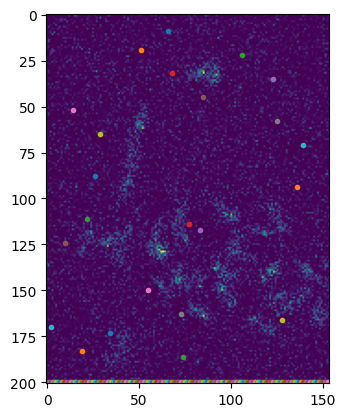

In [62]:
a = flourescence_in.element_maps[2].counts_per_second
plt.imshow(a)
n = len(invalid_coords[0])
for i in range(n):
    plt.plot(invalid_coords[1][i], invalid_coords[0][i], '.')
plt.show()

In [71]:
i=30
flourescence_in.element_maps[2].counts_per_second[invalid_coords[0][i], invalid_coords[1][i]]

np.float32(0.0)

In [74]:
np.where(flourescence_in.element_maps[2].counts_per_second==0)[0]

array([  0,   0,   0, ..., 200, 200, 200], shape=(7610,))

In [ ]:
# load 
with h5py.File("/local/development/2026/ptycho_enhanced_fluorescence/test_data/bnp_isaure_fly0085/data_roi0_Ndp128_para.hdf5", "r") as F:
    valid_position_index = F["pos_index"][()]

In [36]:
np.unravel_index(
    valid_position_index, flourescence_in.element_maps[2].counts_per_second.shape
)


(array([  0,   0,   0, ..., 199, 199, 199], shape=(30777,)),
 array([  0,   1,   2, ..., 151, 152, 153], shape=(30777,)))

In [63]:
ptycho_in.probe_positions.shape

(30777, 2)

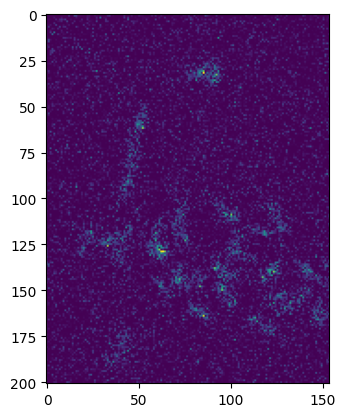

In [42]:
plt.imshow(flourescence_in.element_maps[2].counts_per_second)
plt.show()

In [45]:
np.prod(flourescence_in.element_maps[2].counts_per_second.shape)

np.int64(30954)

In [37]:
flourescence_in.element_maps[2].counts_per_second[valid_position_index]

IndexError: index 201 is out of bounds for axis 0 with size 201